# Mortality Study 02
## Intro to Visualization

## Setup
1. Manually enter a smaller subset of data for easy analysis
2. Remove spaces from column names
3. Load the full data set to be ready-to-go (or use as an alternative).
4. Load a small dataset with nulls (or errors)

In [434]:
import pandas as pd

### SMALL DATA SET:  Manually enter a smaller subset of data
#### DATA FRAME NAME: "mortality_data"

In [435]:
# Adding a null value to check counts
# 1900, '1-4 Years', None
# 1900, '1-4 Years', 1983.8

df_data=[[1900, '1-4 Years', 1983.8], 
         [1901, '1-4 Years', 1695.0],
         [1902, '1-4 Years', 1655.7],
         [1903, '1-4 Years', 1542.1],
         [1904, '1-4 Years', 1591.5],
         [1905, '1-4 Years', 1498.9],
         [1906, '1-4 Years', 1580.0],
         [1907, '1-4 Years', 1468.3],
         [1908, '1-4 Years', 1396.8],
         [1909, '1-4 Years', 1348.9],
         [1900, '5-9 Years', 466.1], 
         [1901, '5-9 Years', 427.6],
         [1902, '5-9 Years', 403.3],
         [1903, '5-9 Years', 414.7],
         [1904, '5-9 Years', 425.0],
         [1905, '5-9 Years', 396.3],
         [1906, '5-9 Years', 377.4],
         [1907, '5-9 Years', 365.6],
         [1908, '5-9 Years', 354.2],
         [1909, '5-9 Years', 330.2]]

df_columns=['Year', 'Age Group', 'Death Rate']

mortality_data = pd.DataFrame(data=df_data, columns=df_columns)

### FULL DATA SET (Alternative):  look at the full dataset.
#### DATA FRAME NAME: "mort_full"
1. Load the csv and create a new data frame, called "mort_full"

In [436]:
mort_full = pd.read_csv("mortality.csv")

## Clean up data 
For both large and small data sets
- Remove spaces from Column Names
- Convert string column values to numbers by adding a leading zero
- Add the mean centered column so we have one more column to use

In [437]:
mortality_data.columns = mortality_data.columns.str.replace(" ", "")

In [438]:
mort_full.columns = mort_full.columns.str.replace(" ", "")

In [439]:
mortality_data.AgeGroup = mortality_data.AgeGroup.replace( {'1-4 Years':'01-04 Years','5-9 Years':'05-09 Years'})

In [440]:
mort_full.AgeGroup = mort_full.AgeGroup.replace( {'1-4 Years':'01-04 Years','5-9 Years':'05-09 Years'})

In [441]:
mortality_data['MeanCentered'] = mortality_data.DeathRate - mortality_data.DeathRate.mean()

In [442]:
mort_full['MeanCentered'] = mort_full.DeathRate - mort_full.DeathRate.mean()

#### Look at the small dataset

In [443]:
mortality_data.head(10)

,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,997.73
1,1901,01-04 Years,1695.0,708.93
2,1902,01-04 Years,1655.7,669.63
3,1903,01-04 Years,1542.1,556.03
4,1904,01-04 Years,1591.5,605.43
5,1905,01-04 Years,1498.9,512.83
6,1906,01-04 Years,1580.0,593.93
7,1907,01-04 Years,1468.3,482.23
8,1908,01-04 Years,1396.8,410.73
9,1909,01-04 Years,1348.9,362.83


#### Look at the full dataset

In [444]:
mort_full.head(10)

,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,1790.87584
1,1901,01-04 Years,1695.0,1502.07584
2,1902,01-04 Years,1655.7,1462.77584
3,1903,01-04 Years,1542.1,1349.17584
4,1904,01-04 Years,1591.5,1398.57584
5,1905,01-04 Years,1498.9,1305.97584
6,1906,01-04 Years,1580.0,1387.07584
7,1907,01-04 Years,1468.3,1275.37584
8,1908,01-04 Years,1396.8,1203.87584
9,1909,01-04 Years,1348.9,1155.97584


In [445]:
mort_full.tail(10)

,Year,AgeGroup,DeathRate,MeanCentered
466,2009,15-19 Years,51.9,-141.02416
467,2010,15-19 Years,49.4,-143.52416
468,2011,15-19 Years,48.9,-144.02416
469,2012,15-19 Years,47.2,-145.72416
470,2013,15-19 Years,44.8,-148.12416
471,2014,15-19 Years,45.5,-147.42416
472,2015,15-19 Years,48.3,-144.62416
473,2016,15-19 Years,51.2,-141.72416
474,2017,15-19 Years,51.5,-141.42416
475,2018,15-19 Years,49.2,-143.72416


## Grouping and Aggregation 
- You can group on a column so that you can apply methods to a group, e.g. statistics
- You will group on the one of the columns. 
    - Since there are multiple values for "Year" and "Age Group" these are great choices. 
    - Statistics on some columns (e.g. year) won't make sense
    - Use the small dataset to check your results
    - The mean for the year 1900 (small data set) is 1224.95

In [446]:
mort_full.groupby('AgeGroup').mean()

,Year,DeathRate,MeanCentered
AgeGroup,,,
01-04 Years,1959.0,383.226050,190.301891
05-09 Years,1959.0,117.326050,-75.598109
10-14 Years,1959.0,93.769748,-99.154412
15-19 Years,1959.0,177.374790,-15.549370


In [447]:
mortality_data.groupby('Year')[['DeathRate']].mean()

,DeathRate
Year,
1900,1224.95
1901,1061.30
1902,1029.50
1903,978.40
1904,1008.25
1905,947.60
1906,978.70
1907,916.95
1908,875.50


In [448]:
mortality_data.groupby('Year')[['DeathRate']].min()

,DeathRate
Year,
1900,466.1
1901,427.6
1902,403.3
1903,414.7
1904,425.0
1905,396.3
1906,377.4
1907,365.6
1908,354.2


### Challenge:   Group by multiple columns and count the values in each group

```
<DataFrameName>.groupby([<List of column names]).function()
```

In [449]:
mortality_data.groupby(['Year', 'AgeGroup']).count()

DeathRate  MeanCentered
Year AgeGroup                            
1900 01-04 Years          1             1
     05-09 Years          1             1
1901 01-04 Years          1             1
     05-09 Years          1             1
1902 01-04 Years          1             1
     05-09 Years          1             1
1903 01-04 Years          1             1
     05-09 Years          1             1
1904 01-04 Years          1             1
     05-09 Years          1             1
1905 01-04 Years          1             1
     05-09 Years          1             1
1906 01-04 Years          1             1
     05-09 Years          1             1
1907 01-04 Years          1             1
     05-09 Years          1             1
1908 01-04 Years          1             1
     05-09 Years          1             1
1909 01-04 Years          1             1
     05-09 Years          1             1

### Applying more than one method to a group

In [450]:
mortality_data.groupby('AgeGroup').agg(['mean','median'])

Year         DeathRate          MeanCentered        
               mean  median      mean   median         mean  median
AgeGroup                                                           
01-04 Years  1904.5  1904.5   1576.10  1561.05       590.03  574.98
05-09 Years  1904.5  1904.5    396.04   399.80      -590.03 -586.27

### Challenge:
- It doesn't make sense to look at the mean and the median for the year.
- Aggregate the data on must the DeathRate
- Add a list of more functions 
- Remember to use quotes around each element of your list values and separate by commas.

```
mortality_data.groupby('AgeGroup')[<Select Columns>].agg([<List of functions>])
```

In [451]:
mortality_data.groupby('AgeGroup')['DeathRate'].agg(['mean','median','std','nunique'])

,mean,median,std,nunique
AgeGroup,,,,
01-04 Years,1576.10,1561.05,179.335204,10
05-09 Years,396.04,399.80,40.143664,10


## Basic Plotting in Pandas

### Simple Example: Plot on Wide Data that has been pivoted
- We could choose "DeathRate" or "MeanCentered" as the data

In [452]:
mort_simple_wide = mortality_data.pivot(index='Year', columns='AgeGroup')['DeathRate']
mort_simple_wide

AgeGroup,01-04 Years,05-09 Years
Year,,
1900,1983.8,466.1
1901,1695.0,427.6
1902,1655.7,403.3
1903,1542.1,414.7
1904,1591.5,425.0
1905,1498.9,396.3
1906,1580.0,377.4
1907,1468.3,365.6
1908,1396.8,354.2


<Axes: xlabel='Year'>

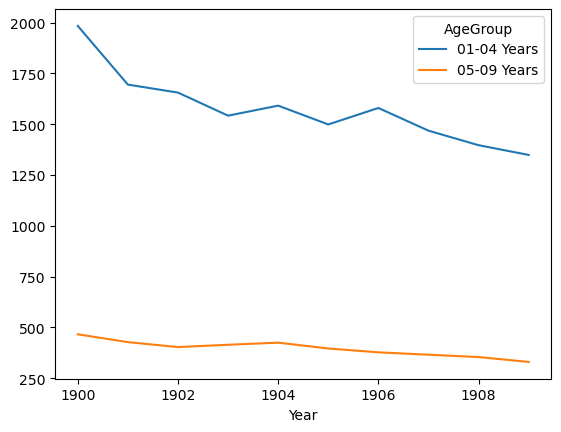

In [453]:
mort_simple_wide = mortality_data.pivot(index='Year', columns='AgeGroup')['DeathRate']
mort_simple_wide.plot()

### Plot on Long Data that has been grouped

# Creating different kinds of plots
## Using a both the simple data set in wide form and the full dataset in long form. 

## 1. Line Plot (Default)
### Small dataset/wide
- **Pros:**
  - Excellent for showing trends over time.
  - Makes it easy to compare changes across age groups.
  - Clean and familiar for time series.
- **Cons:**
  - Can become cluttered with too many age groups.
  - Doesn’t show variation within a year.


<Axes: xlabel='Year'>

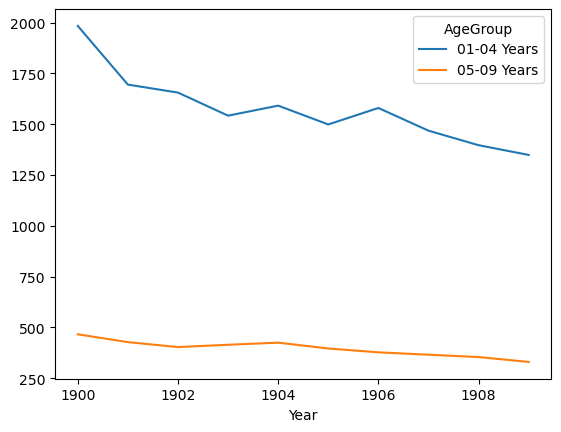

In [454]:
# Default is line
mort_simple_wide.plot.line()

## Improving the appearance of a plot (Simple Data Set)

<Axes: title={'center': 'Child Mortality: 1900-1909'}, xlabel='Year', ylabel='Deaths per 100k'>

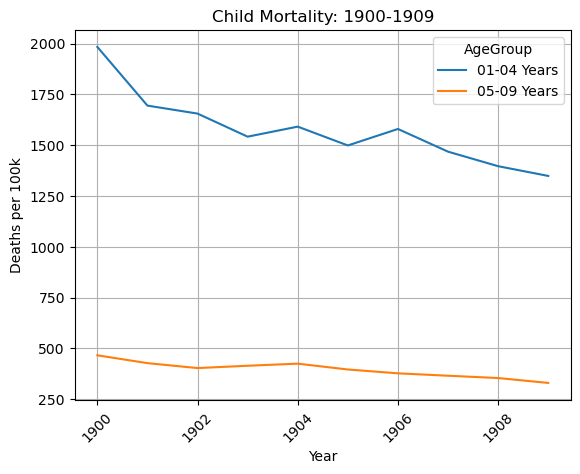

In [455]:
mort_simple_wide.plot.line(title='Child Mortality: 1900-1909', ylabel='Deaths per 100k', grid=True, rot=45)

## Improving the appearance of a plot (Full Data Set)

In [463]:
mortality_full_wide = mort_full.pivot(index='Year', columns='AgeGroup', values='DeathRate')
mortality_full_wide.tail(5)

AgeGroup,01-04 Years,05-09 Years,10-14 Years,15-19 Years
Year,,,,
2014,24.0,11.5,14.0,45.5
2015,24.9,11.7,14.6,48.3
2016,25.3,12.2,14.6,51.2
2017,24.3,11.6,15.5,51.5
2018,24.0,11.5,14.9,49.2


<Axes: title={'center': 'Child Mortality: 1900-2020'}, xlabel='Year', ylabel='Deaths per 100k'>

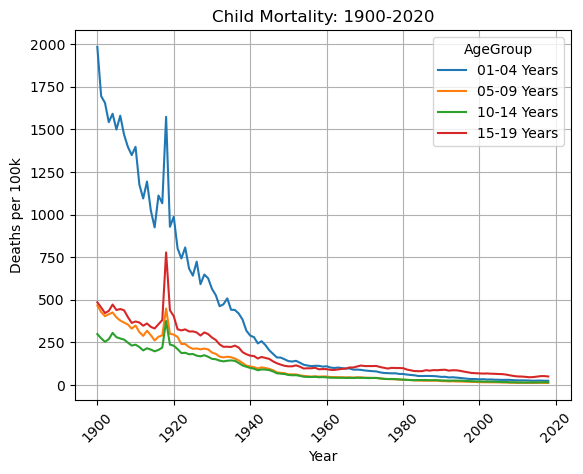

In [464]:
mortality_full_wide.plot.line(title='Child Mortality: 1900-2020', ylabel='Deaths per 100k', grid=True, rot=45)

## 2. Area Plot
### Small dataset/wide
- **Pros:**
  - Good for showing cumulative death rates or how age groups contribute to a total.
  - Visually emphasizes volume.
- **Cons:**
  - Overlapping areas can obscure data.
  - Harder to read individual trends for each age group.

<Axes: xlabel='Year'>

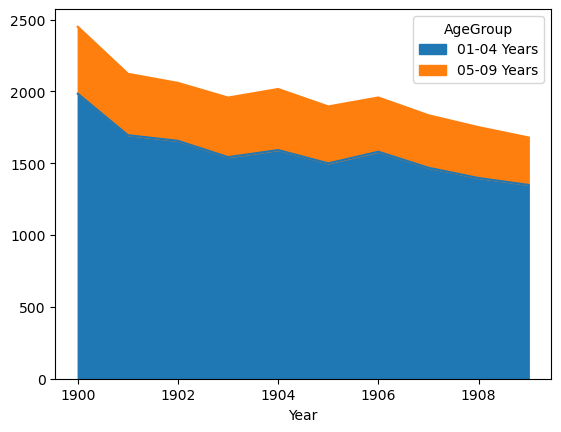

In [456]:
mort_simple_wide.plot.area()

## 3. Scatter Plot
### Full data set, long

- **Pros:**
  - Good for spotting individual outliers or unusual data points.
  - Works well with non-continuous or irregular time intervals.
- **Cons:**
  - Doesn’t clearly show trends unless overlaid with lines.
  - Can be noisy if there are too many points.

<Axes: xlabel='Year', ylabel='DeathRate'>

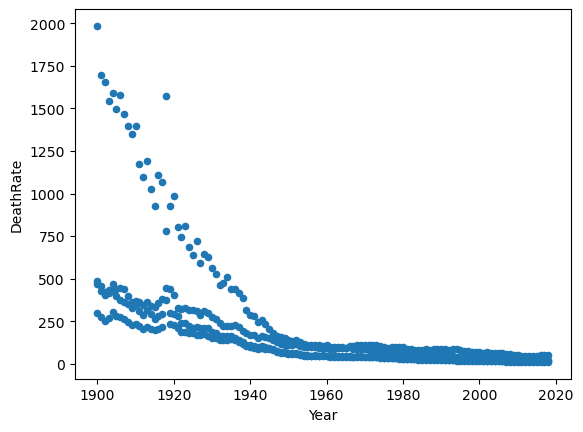

In [457]:
mort_full.plot.scatter(x='Year', y='DeathRate')

## 4. Bar Plot (Grouped or Stacked)
### Small dataset/wide
- **Pros:**
  - Clear comparison of death rates at specific years.
  - Stacked bars can show total and parts (age groups).
- **Cons:**
  - Not ideal for visualizing long time series.
  - Hard to interpret trends across years.

<Axes: xlabel='Year'>

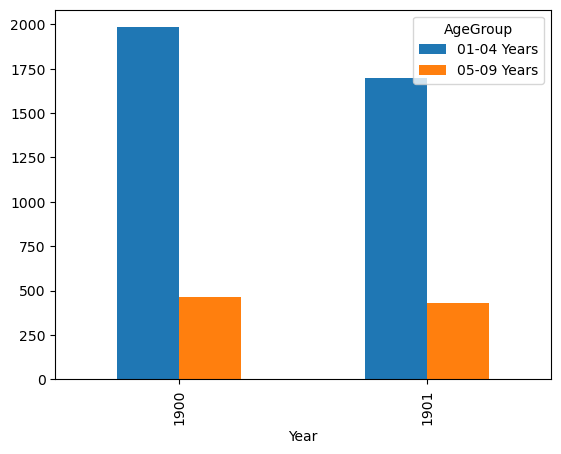

In [458]:
mort_simple_wide.query('Year in (1900,1901)').plot.bar()

## 5. Histogram
### Full data set, long
- **Pros:**
  - Good for showing distribution of death rates (not trends).
  - Helps identify skewness and modality.
- **Cons:**
  - Not suitable for showing changes over time.
  - Doesn’t use the year axis meaningfully.

<Axes: ylabel='Frequency'>

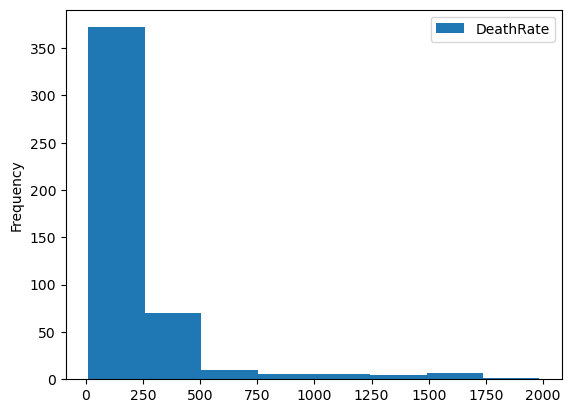

In [459]:
mort_full.plot.hist(y='DeathRate', bins=8)

## 6. Density Plot (KDE)
- **Pros:**
  - Smooth version of a histogram.
  - Helps compare death rate distributions between age groups.
- **Cons:**
  - Not time-based; like histograms, it ignores the year.
  - Smoothing may hide actual data characteristics.


<Axes: ylabel='Frequency'>

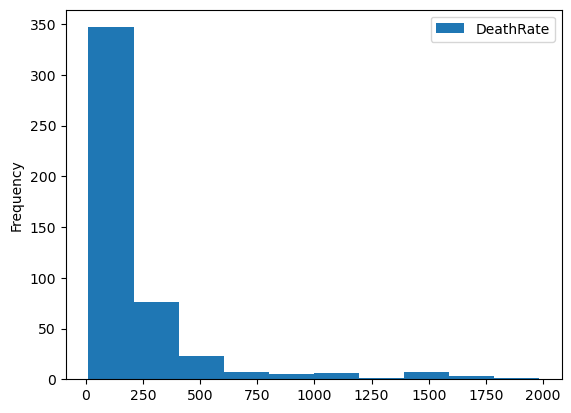

In [460]:
mort_full.plot.hist(y='DeathRate')

## 7. Box Plot
### Small dataset/wide
- **Pros:**
  - Great for summarizing distribution (median, quartiles, outliers) by year or age group.
  - Helps detect age groups with high variability in death rate.
- **Cons:**
  - Doesn’t show trends or exact values well.
  - Less intuitive for beginners.


<Axes: >

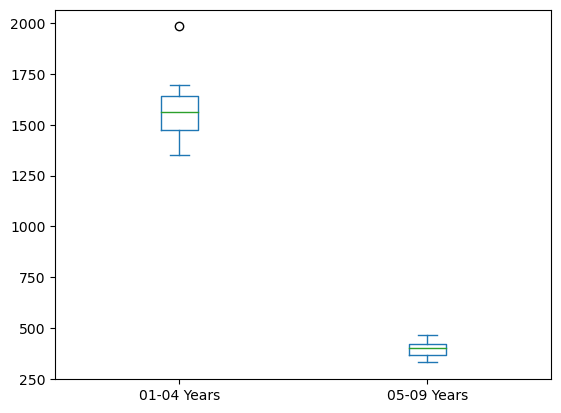

In [461]:
mort_simple_wide.plot.box()

## 8. Pie Chart
### Full data set, long
- **Pros:**
  - Simple way to show percentage contribution of each age group in a **single year**.
  - Visually engaging for small sets.
- **Cons:**
  - Poor at showing trends over time.
  - Hard to compare multiple pies across years.

<Axes: ylabel='DeathRate'>

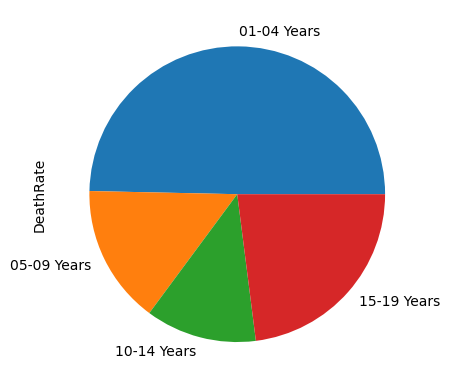

In [462]:
mort_full.groupby('AgeGroup')['DeathRate'].sum().plot.pie()